In [44]:
import time

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import QuantileTransformer
from scipy.stats import spearmanr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

import utils.data as datutils
import utils.file as futils

import warnings
from pandas.errors import ParserWarning

warnings.simplefilter(action='ignore', category=ParserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# Load data

mah_dict = futils.get_mah_all()
ma, _, aexp_bins = datutils.interp_ma(mah_dict)
am, mass_bins = datutils.build_am(ma=ma, scales=aexp_bins,
                                min_mass_bin=0.01, log_spacing=True)

stacked_ma = np.vstack([ma]*3)  # because we have 3 projections
stacked_am = np.vstack([am]*3)  # because we have 3 projections

halo_ids = np.array([int(k) for k in mah_dict.keys()])
m14 = futils.get_m14(halo_ids)
m14_stacked = np.hstack([m14['proj_x'], m14['proj_y'], m14['proj_y']])

dsdf = futils.get_ds(halo_ids)
# dsdf.reset_index(inplace=True)
dsdf.drop(columns=['eta_500[8]', 'delta_500[9]',
          'fm_500[10]', 'fm2_500[11]'], inplace=True)
smdf = futils.get_morphologies(halo_ids)
inner_df = futils.get_morphologies(halo_ids, 'r_0.03Mpc_205.csv')
iconc = inner_df['C']

ahf = futils.get_ahf_all()
mass = np.array([ahf[halo_id]['Mvir(4)'][ahf[halo_id]['Redshift(0)'] == 0].values[0] 
           for halo_id in halo_ids])
logmass = np.log10(mass)
logmass_stacked = np.hstack([logmass]*3)  # because we have 3 projections

n_halos = len(am)
assert m14_stacked.shape[0] == 3 * n_halos
assert stacked_am.shape[0] == 3 * n_halos
assert stacked_ma.shape[0] == 3 * n_halos
assert smdf.shape[0] == 3 * n_halos
assert iconc.shape[0] == 3 * n_halos

/Users/kabelo/clusters/utils/data.py:342: RuntimeWarning: invalid value encountered in log
  np.log(_m_peaks), np.log(_scales), bounds_error=False, fill_value=np.nan


In [3]:
smdf.columns

Index(['rhalf_circ', 'C', 'A', 'sersic_amplitude'], dtype='object')

In [73]:
start = time.time()
state = 5
n_halos = len(am)
halo_idx = np.arange(n_halos)
train_idx, test_idx = train_test_split(
    halo_idx, test_size=0.25, random_state=state)

# x = np.vstack((dsdf.to_numpy().T, m14.to_numpy().T)).T
# y = am
# x_train = x[train_idx]
# x_test = x[test_idx]
# y_train = y[train_idx]
# y_test = y[test_idx]
    

# Stack indices across all 3 projections
stacked_train_idx = np.concatenate(
    [train_idx, train_idx + n_halos, train_idx + 2*n_halos])
stacked_test_idx = np.concatenate(
    [test_idx,  test_idx + n_halos, test_idx + 2*n_halos])

# x_train = np.vstack([smdf_proj.to_numpy()[train_idx]
#                     for smdf_proj in [sm_df_xy, sm_df_yz, sm_df_zx]])

x_train = np.concatenate([smdf.to_numpy()[stacked_train_idx],
                        #   m14_stacked[:, None][stacked_train_idx],
                          iconc.to_numpy()[:, None][stacked_train_idx]], 
                          axis=1)
                          
x_test = np.concatenate([smdf.to_numpy()[stacked_test_idx],
                        #  m14_stacked[:, None][stacked_test_idx],
                         iconc.to_numpy()[:, None][stacked_test_idx]], 
                         axis=1)
y_train = stacked_am[stacked_train_idx]
y_test = stacked_am[stacked_test_idx]
xgb_r2 = np.zeros_like(mass_bins)
xgb_rmse = np.zeros_like(mass_bins)
for i, m in enumerate(mass_bins):
    # m = 0.5
    mhalf_indx = np.argmin(np.abs(mass_bins-m))
    a50_test = y_test[:, mhalf_indx]
    a50_train = y_train[:, mhalf_indx]

    qt = QuantileTransformer(output_distribution='normal', random_state=state)
    x_train_qt = qt.fit_transform(x_train)
    x_test_qt = qt.transform(x_test)  

    regressor = xgb.XGBRegressor(random_state=state, learning_rate=0.05, max_depth=2, n_estimators=100)
    # parameter_space = {'learning_rate': [0.01, 0.05, 0.1],
    #                 'max_depth': [1, 2, 3],
    #                 'n_estimators': [100, 250, 500]}

    # reg = GridSearchCV(model, parameter_space, cv=5, scoring='r2', verbose=1)
    regressor.fit(x_train_qt, a50_train)
    # regressor = reg.best_estimator_

    # print(reg.best_params_)
    # print('  ... training took %.2f seconds' % (time.time() - start))
    preds = regressor.predict(x_test_qt)
    residuals = preds - a50_test
    r2 = r2_score(a50_test, preds)
    xgb_r2[i] = r2
    # print(f'r2 : {r2}')
    rmse = np.sqrt(mean_squared_error(a50_test, preds))
    xgb_rmse[i] = rmse
    # print(f'rmse : {rmse}')
    # baseline: predict train mean
    mean_pred = np.full_like(a50_test, a50_train.mean())
    # print('baseline mean r2:', r2_score(a50_test, mean_pred))

/Users/kabelo/anaconda3/envs/cluster_morph/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (459). n_quantiles is set to n_samples.
  warnings.warn(
/Users/kabelo/anaconda3/envs/cluster_morph/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (459). n_quantiles is set to n_samples.
  warnings.warn(
/Users/kabelo/anaconda3/envs/cluster_morph/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (459). n_quantiles is set to n_samples.
  warnings.warn(
/Users/kabelo/anaconda3/envs/cluster_morph/lib/python3.13/site-packages/sklearn/preprocessing/_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (459). n_quantiles is set to n_samples.
  warnings.warn(
/Users/kabelo/anaconda3/envs/clu

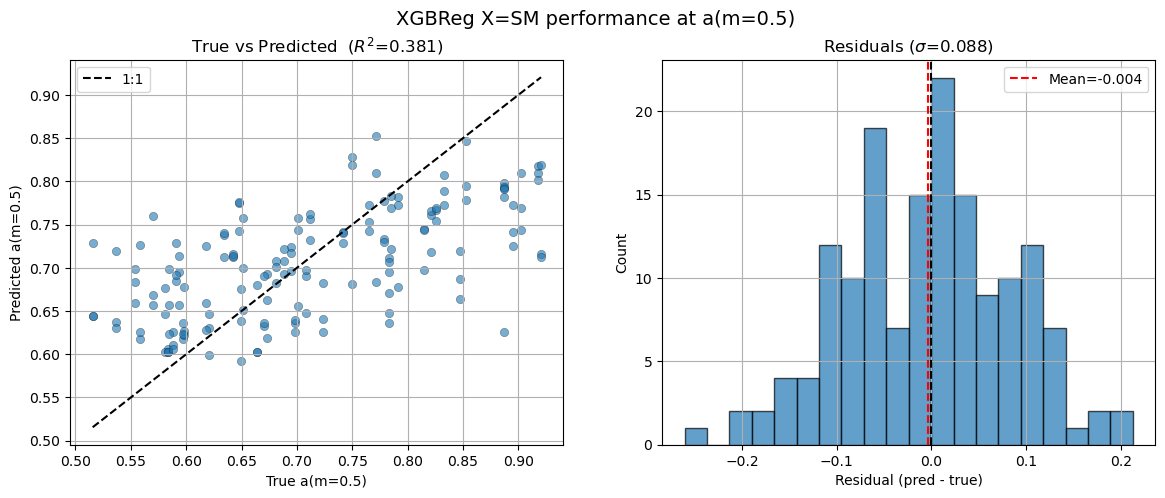

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

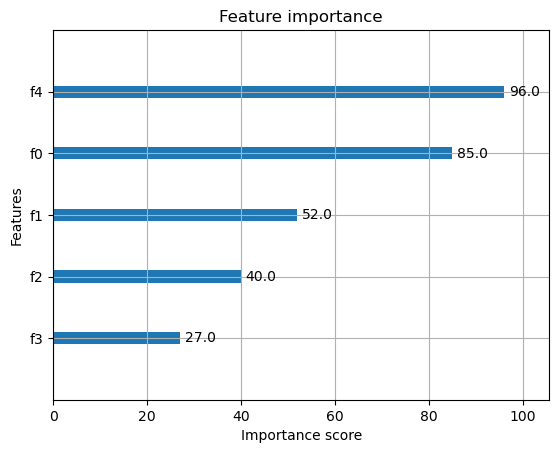

In [66]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'XGBReg X=SM performance at a(m={m})', fontsize=14)

# true vs predicted
axs[0].scatter(a50_test, preds, alpha=0.6, edgecolors='k', linewidths=0.3)
lims = [min(a50_test.min(), preds.min()), max(a50_test.max(), preds.max())]
axs[0].plot(lims, lims, 'k--', label='1:1')
axs[0].set_xlabel(f'True a(m={m})')
axs[0].set_ylabel(f'Predicted a(m={m})')
axs[0].set_title(f'True vs Predicted  ($R^2$={r2:.3f})')
axs[0].legend()
axs[0].grid()

# Residual histogram
axs[1].hist(residuals, bins=20, edgecolor='k', alpha=0.7)
axs[1].axvline(0, color='k', linestyle='--')
axs[1].axvline(residuals.mean(), color='red', linestyle='--',
               label=f'Mean={residuals.mean():.3f}')
axs[1].set_xlabel('Residual (pred - true)')
axs[1].set_ylabel('Count')
axs[1].set_title(rf'Residuals ($\sigma$={residuals.std():.3f})')
axs[1].legend()
axs[1].grid()

# # these names are NOT always correct, just for quick plotting
# x_test_rh = x_test[:, 0]
# x_test_conc = x_test[:, 1]
# x_test_A = x_test[:, 2]
# x_test_sa = x_test[:, 3]
# x_test_m14 = x_test[:, 4]
# x_test_cc = x_test[:, 5]

# sc = axs[1].scatter(a50_test, residuals, c=x_test_cc)   
# axs[1].axhline(0, color='k', linestyle='--')
# axs[1].set_xlabel(f'True a(m={m})')
# axs[1].set_ylabel('Residual (pred - true)')
# plt.colorbar(sc, ax=axs[1], label='Core Concentration')

plt.show()

xgb.plot_importance(regressor)

In [67]:
for feature in [smdf['rhalf_circ'], smdf['C'], smdf['A'],
                smdf['sersic_amplitude'], iconc, m14_stacked]:
    feature = feature.to_numpy() if isinstance(feature, pd.Series) else feature
    corr = spearmanr(residuals, feature[stacked_test_idx]).correlation
    print(f'{corr:.3f}')

-0.076
0.074
-0.143
0.114
-0.150
0.153


In [68]:
def low_mass_performance():
    med_mass = np.median(mass)
    lidx = halo_idx[mass < med_mass]
    low_idx = np.array([i for i in test_idx if i in lidx])
    low_idx_stacked = np.ravel([low_idx, low_idx + n_halos, low_idx + 2*n_halos])
    x_test = np.concatenate([smdf.to_numpy()[low_idx_stacked],
                            m14_stacked[:, None][low_idx_stacked],
                            logmass_stacked[:, None][low_idx_stacked],
                            iconc.to_numpy()[:, None][low_idx_stacked]], axis=1)
    x_test = smdf.to_numpy()[low_idx_stacked]
    y_test = stacked_am[low_idx_stacked]

    m = 0.5
    mhalf_indx = np.argmin(np.abs(mass_bins-m))
    a50_test = y_test[:, mhalf_indx]

    x_test_qt = qt.transform(x_test)
    preds = regressor.predict(x_test_qt)
    residuals = preds - a50_test
    r2 = r2_score(a50_test, preds)
    print('-------- xgboost low mass sample [sm]-------')
    print(f'r2 : {r2}')
    print(f'rmse : {np.sqrt(mean_squared_error(a50_test, preds))}')
    # baseline: predict train mean
    mean_pred = np.full_like(a50_test, a50_train.mean())
    print('baseline mean r2:', r2_score(a50_test, mean_pred))

In [69]:
test_idx

array([154,  21, 198,  48,  34, 194,   6,  25, 159, 122, 139,  26, 140,
       134, 177, 187,  84,  71,  77,  93, 152,  87,  42, 117,  61,  28,
         3, 153, 200,  54, 185,  95, 204, 191,  39, 148,  56,  17, 126,
        51,  40,  46, 183,  98, 197, 101, 115,  24,  74, 111,  50,  53])

In [74]:
mcam_r2 = np.array([-2.53639267, -2.36175448, -2.32634513, -2.32245105, -2.34604808,
                    -2.56298719, -2.61103977, -2.56230302, -1.8965369, -1.82816812,
                    -1.55540248, -1.44166136, -1.37378454, -1.32819666, -1.32228124,
                    -1.32019072, -1.35044356, -1.36516363, -1.3286154, -1.28457474,
                    -1.22866488, -1.16511828, -1.16714661, -1.16328684, -0.99065484,
                    -0.90030792, -0.88010367, -0.88603794, -0.87270499, -0.84918773,
                    -0.94466946, -0.94979994, -0.95843031, -1.00869427, -0.77087474,
                    -0.68737271, -0.77375852, -0.77080782, -0.79458688, -0.76509263,
                    -0.59855221, -0.64691644, -0.67040335, -0.68518356, -0.69210153,
                    -0.84642251, -0.83787894, -0.8463957, -0.80588081, -0.80591562,
                    -0.85972585, -0.87262743, -0.88981469, -0.58407411, -0.37436232,
                    -0.20958618, -0.21656142, -0.21249489, -0.23124339, -0.23428834,
                    -0.23485119, -0.21534742, -0.21767962, -0.24906524, -0.27172894,
                    -0.28068316, -0.29491011, -0.28216609, -0.24287037, -0.25325107,
                    -0.26853104, -0.23091491, -0.25113412, -0.27976842, -0.16998931,
                    -0.18789067, -0.19767378, -0.15883136, -0.07305632,  0.12187063,
                    0.20776479,  0.25321802,  0.24980256,  0.25709862,  0.21551833,
                    0.15393415,  0.11795211,  0.07579784,  0.0691427,  0.09059916,
                    0.06821837,  0.0704877,  0.01816803, -0.03585934, -0.26129692,
                    -0.28153367, -0.19159284, -0.32038873, -0.63817434, -0.46060264])

mcam_rmse = np.array([0.07742291, 0.07672858, 0.07741012, 0.07835679, 0.07946304,
                      0.08223974, 0.08290441, 0.0834356, 0.07600513, 0.07585172,
                      0.07259055, 0.07135153, 0.0707697, 0.07029438, 0.07017128,
                      0.06986626, 0.07062582, 0.07097198, 0.07129035, 0.07122501,
                      0.07182182, 0.07173243, 0.07229114, 0.07310916, 0.07272305,
                      0.07175868, 0.07227573, 0.07333325, 0.07403683, 0.07479561,
                      0.0803621, 0.08197581, 0.0839022, 0.08623989, 0.08227671,
                      0.08249406, 0.09129701, 0.0924014, 0.09376906, 0.09391381,
                      0.09690523, 0.09987139, 0.10004071, 0.10011122, 0.09973942,
                      0.10317348, 0.10205689, 0.10174295, 0.10432826, 0.10435204,
                      0.10479538, 0.1062472, 0.10658214, 0.0976775, 0.09333245,
                      0.0897199, 0.09683509, 0.09858829, 0.09982662, 0.10005219,
                      0.0997644, 0.09901748, 0.09804424, 0.0985527, 0.0972106,
                      0.09649935, 0.09576005, 0.09526335, 0.09525523, 0.09695384,
                      0.09798766, 0.09761634, 0.09891992, 0.10683259, 0.10839449,
                      0.11001219, 0.11064354, 0.11091309, 0.10909747, 0.10098793,
                      0.0998246, 0.09892949, 0.10040086, 0.09959571, 0.09867097,
                      0.1000357, 0.10064385, 0.10178188, 0.10150232, 0.1011822,
                      0.10103466, 0.09993155, 0.10231258, 0.09992713, 0.10478003,
                      0.10289962, 0.09356412, 0.09386293, 0.08766231, 0.06565646])

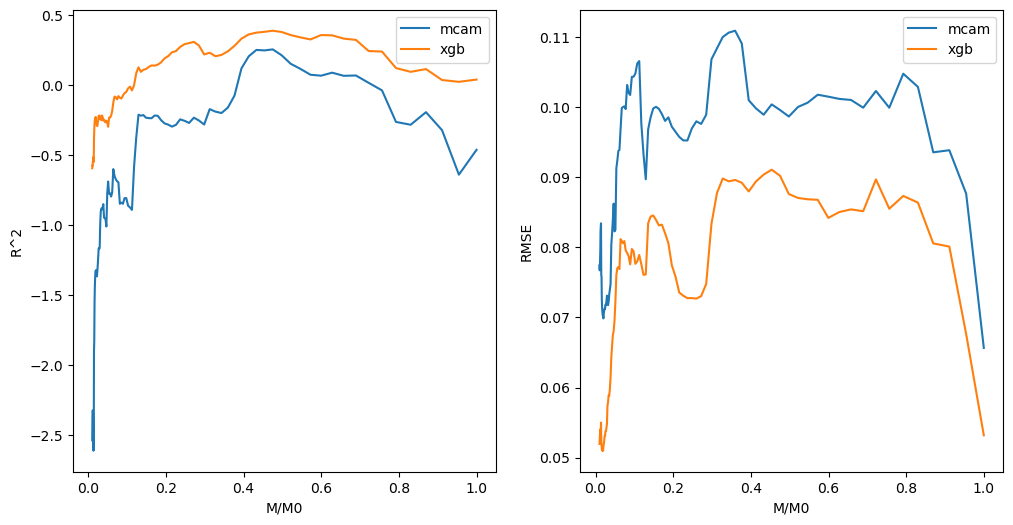

In [82]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(mass_bins, mcam_r2, label='mcam')
axs[0].plot(mass_bins, xgb_r2, label='xgb')
axs[0].set_xlabel('M/M0')
axs[0].set_ylabel('R^2')
axs[0].legend()
axs[1].plot(mass_bins, mcam_rmse, label='mcam')
axs[1].plot(mass_bins, xgb_rmse, label='xgb')
axs[1].set_xlabel('M/M0')
axs[1].set_ylabel('RMSE')
axs[1].legend()
plt.show()